In [102]:
import pandas as pd

df = pd.read_csv("alfabank_reviews.csv")

print("Пропуски до очистки:")
print(df.isnull().sum())

df = df.replace("", pd.NA)
df_clean = df.dropna()

print("\nПосле очистки:")
print(df_clean.isnull().sum())
print(f"\nРазмер до: {len(df)}")
print(f"Размер после: {len(df_clean)}")
df_clean.to_csv("alfabank_reviews_clean.csv", index=False)


Пропуски до очистки:
title     500
rating    500
text      500
date      500
time      500
target    500
dtype: int64

После очистки:
title     0
rating    0
text      0
date      0
time      0
target    0
dtype: int64

Размер до: 13000
Размер после: 12500


In [103]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter


In [104]:
df = pd.read_csv("alfabank_reviews_clean.csv")

print("Колонки:", df.columns.tolist())
print(df.head())

TEXT_COL = "text"
LABEL_COL = "target"

df = df[[TEXT_COL, LABEL_COL]].dropna()

df = df[df[LABEL_COL].isin(["positive", "negative"])]

print("Уникальные таргеты после фильтрации:", df[LABEL_COL].unique())

label_map = {"positive": 0, "negative": 1}
df["label_id"] = df[LABEL_COL].map(label_map)

texts = df[TEXT_COL].astype(str).tolist()
labels = df["label_id"].astype(int).tolist()

print("Всего объектов:", len(texts))
print("Распределение классов:", Counter(labels))


Колонки: ['title', 'rating', 'text', 'date', 'time', 'target']
                           title  rating  \
0  Отзыв о сотруднике Альфа Банк     5.0   
1           Отзыв об Альфа-Банке     5.0   
2                   Открытие РКО     5.0   
3      Альфа банк, надёжный банк     5.0   
4  Категории повышенного кэшбэка     5.0   

                                                text        date   time  \
0  23 ноября написал в поддержку из-за того, что ...  25.11.2025  12:54   
1  11.11.25 обращался в поддержку Альфа-банка с п...  24.11.2025  19:31   
2  21.11.2025 в 15:14 ко  мне приехала сотрудник ...  21.11.2025  15:39   
3  Обратился в чат поддержки Альфа-Банка 28.10.20...  21.11.2025  15:20   
4  Доброго времени!\r\n20 ноября в 15:18 я обрати...  21.11.2025  15:14   

     target  
0  positive  
1  positive  
2  positive  
3  positive  
4  positive  
Уникальные таргеты после фильтрации: ['positive' 'negative']
Всего объектов: 12473
Распределение классов: Counter({0: 11967, 1: 506})


In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Train class distribution:", Counter(y_train))
print("Test class distribution:", Counter(y_test))


Train size: 9978
Test size: 2495
Train class distribution: Counter({0: 9573, 1: 405})
Test class distribution: Counter({0: 2394, 1: 101})


In [106]:
# 1. TF-IDF для текстов (train и test)
tfidf = TfidfVectorizer(max_features=20000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_dense = X_train_tfidf.toarray().astype(np.float32)
X_test_dense = X_test_tfidf.toarray().astype(np.float32)

# 2. Применим SMOTE на train и test
print("До SMOTE - train:", Counter(y_train))
print("До SMOTE - test:", Counter(y_test))

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_dense, y_train)
X_test_resampled, y_test_resampled = smote.fit_resample(X_test_dense, y_test)

print("После SMOTE - train:", Counter(y_train_resampled))
print("После SMOTE - test:", Counter(y_test_resampled))


До SMOTE - train: Counter({0: 9573, 1: 405})
До SMOTE - test: Counter({0: 2394, 1: 101})
После SMOTE - train: Counter({0: 9573, 1: 9573})
После SMOTE - test: Counter({0: 2394, 1: 2394})


In [108]:
class TfidfDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return {
            "features": torch.from_numpy(self.X[idx]),
            "label": torch.tensor(self.y[idx], dtype=torch.long)
        }

train_dataset = TfidfDataset(X_train_resampled, y_train_resampled)
test_dataset = TfidfDataset(X_test_resampled, y_test_resampled)
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



In [109]:
class TfidfMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, num_classes)

    def forward(self, x):
        h = self.fc1(x)
        h = self.relu(h)
        h = self.dropout(h)

        h = self.fc2(h)
        h = self.relu(h)
        h = self.dropout(h)

        logits = self.fc3(h)
        return logits, h

In [110]:
input_dim = X_train_resampled.shape[1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TfidfMLP(input_dim=input_dim, hidden_dim=256, num_classes=2, dropout=0.5)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

writer = SummaryWriter(log_dir="runs/alfabank_tfidf_mlp_tuned")



In [111]:
def train_one_epoch(model, dataloader, optimizer, criterion, device, epoch):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        feats = batch["features"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits, _ = model(feats)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * feats.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    p_bin, r_bin, f1_bin, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", pos_label=1
    )

    writer.add_scalar("Loss/train", epoch_loss, epoch)
    writer.add_scalar("Accuracy/train", acc, epoch)
    writer.add_scalar("NegPrecision/train", p_bin, epoch)
    writer.add_scalar("NegRecall/train", r_bin, epoch)
    writer.add_scalar("NegF1/train", f1_bin, epoch)

    print(f"[TRAIN] epoch {epoch}, loss: {epoch_loss:.4f}, acc: {acc:.4f}, "
          f"neg_precision: {p_bin:.4f}, neg_recall: {r_bin:.4f}, neg_f1: {f1_bin:.4f}")
    return epoch_loss, acc, p_bin, r_bin, f1_bin


def evaluate(model, dataloader, criterion, device, epoch=None, prefix="test"):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            feats = batch["features"].to(device)
            labels = batch["label"].to(device)

            logits, _ = model(feats)
            loss = criterion(logits, labels)

            running_loss += loss.item() * feats.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    p_bin, r_bin, f1_bin, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", pos_label=1
    )
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro"
    )

    if epoch is not None:
        writer.add_scalar(f"Loss/{prefix}", epoch_loss, epoch)
        writer.add_scalar(f"Accuracy/{prefix}", acc, epoch)
        writer.add_scalar(f"NegPrecision/{prefix}", p_bin, epoch)
        writer.add_scalar(f"NegRecall/{prefix}", r_bin, epoch)
        writer.add_scalar(f"NegF1/{prefix}", f1_bin, epoch)
        writer.add_scalar(f"MacroF1/{prefix}", f1_macro, epoch)

    print(f"[{prefix.upper()}] loss: {epoch_loss:.4f}, acc: {acc:.4f}, "
          f"neg_precision: {p_bin:.4f}, neg_recall: {r_bin:.4f}, neg_f1: {f1_bin:.4f}, "
          f"macro_f1: {f1_macro:.4f}")

    print(classification_report(all_labels, all_preds,
                                target_names=["positive", "negative"]))
    return epoch_loss, acc, p_bin, r_bin, f1_bin, f1_macro


In [112]:
import numpy as np

class EarlyStopping:
    def __init__(self, patience=3, verbose=True, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_wts = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_wts = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_wts)


In [113]:
early_stopping = EarlyStopping(patience=3, verbose=True, delta=0.01)

EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    print("=" * 40)
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss, train_acc, tp, tr, tf1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device, epoch
    )
    val_loss, val_acc, vp, vr, vf1, vmacro = evaluate(
        model, test_loader, criterion, device, epoch, prefix="test"
    )

    early_stopping(vmacro, model)

    if early_stopping.early_stop:
        print("Early stopping")
        break

early_stopping.load_best_model(model)

Epoch 1/10
[TRAIN] epoch 1, loss: 0.1104, acc: 0.9636, neg_precision: 0.9843, neg_recall: 0.9422, neg_f1: 0.9628
[TEST] loss: 3.2522, acc: 0.5453, neg_precision: 0.9465, neg_recall: 0.0961, neg_f1: 0.1744, macro_f1: 0.4304
              precision    recall  f1-score   support

    positive       0.52      0.99      0.69      2394
    negative       0.95      0.10      0.17      2394

    accuracy                           0.55      4788
   macro avg       0.74      0.55      0.43      4788
weighted avg       0.74      0.55      0.43      4788

Epoch 2/10
[TRAIN] epoch 2, loss: 0.0007, acc: 0.9998, neg_precision: 0.9997, neg_recall: 1.0000, neg_f1: 0.9998
[TEST] loss: 3.6794, acc: 0.5491, neg_precision: 0.9502, neg_recall: 0.1036, neg_f1: 0.1868, macro_f1: 0.4374
              precision    recall  f1-score   support

    positive       0.53      0.99      0.69      2394
    negative       0.95      0.10      0.19      2394

    accuracy                           0.55      4788
   macro 

Shape embeddings: (4788, 128)


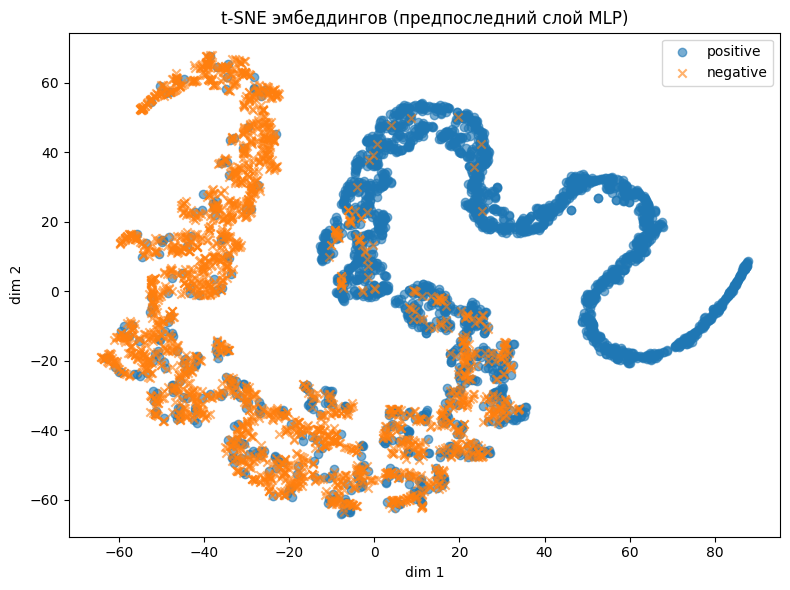

In [114]:
def get_embeddings_and_labels(model, dataloader, device):
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            feats = batch["features"].to(device)
            labels = batch["label"].to(device)

            logits, embeddings = model(feats)
            all_embeddings.append(embeddings.detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_embeddings, all_labels

embeddings, emb_labels = get_embeddings_and_labels(model, test_loader, device)
print("Shape embeddings:", embeddings.shape)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
for cls, name, marker in [(0, "positive", "o"), (1, "negative", "x")]:
    idx = emb_labels == cls
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=name, alpha=0.6, marker=marker)

plt.legend()
plt.title("t-SNE эмбеддингов (предпоследний слой MLP)")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.tight_layout()
plt.show()
